In [2]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(Param_symbol)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [3]:
RUN_ID = 'second'
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(20e3)

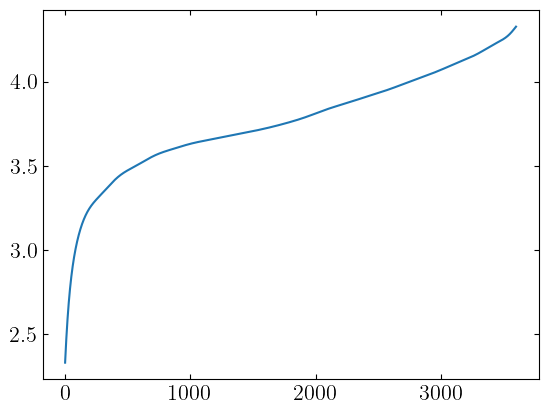

In [ ]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)




In [17]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id R0_second...
Settings: iterations=20000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.11742749
Equation: 3.753417

Model 1: Complexity=3, Loss=0.0184571
Equation: soc - -3.253433

Model 2: Complexity=4, Loss=0.0154842315
Equation: sqrt(soc) - -3.0900552

Model 3: Complexity=6, Loss=0.0056911125
Equation: exp(sqrt(sqrt(soc))) - -1.5074642

Model 4: Complexity=7, Loss=0.0043588285
Equation: sqrt(sqrt(soc * 11.871907)) - -2.279442

Model 5: Complexity=8, Loss=0.0018361225
Equation: soc - (exp(soc * -51.671333) + -3.2822292)

Model 6: Complexity=10, Loss=0.0008952648
Equation: ((soc * 0.878247) - exp(soc * -39.460556)) - -3.349046

Model 7: Complexity=11, Loss=0.00056687003
Equation: ((0.48772275 - exp(soc * -28.983704)) * exp(soc)) - -2.9589064

Model 8: Complexity=12, Loss=0.00048611307
Equation: (exp(soc) * log(1.5946015 - exp(soc * -19.949188))) - -2.9996262

Model 9: Complexity=13, Loss=0.0002263374
Equation: (square(soc + -0.25309715) - -3.7358704) - square(square(sqrt(soc) + -1.0996741))

Model 10: Complexity=14, Loss=0.00017973034
Equat

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (0.31308034 - soc)**2 - (1.4523449 - (2.1701553*soc + (soc**2 + 0.4362697)**6)**(1/4))**3 + 3.8004744
Loss: 4.9486123e-05
Best model complexity: 22


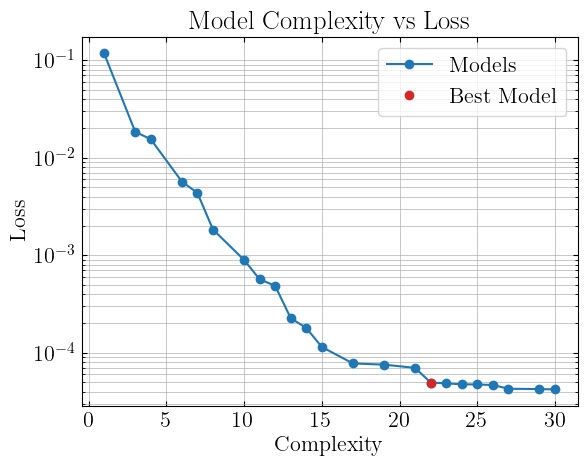

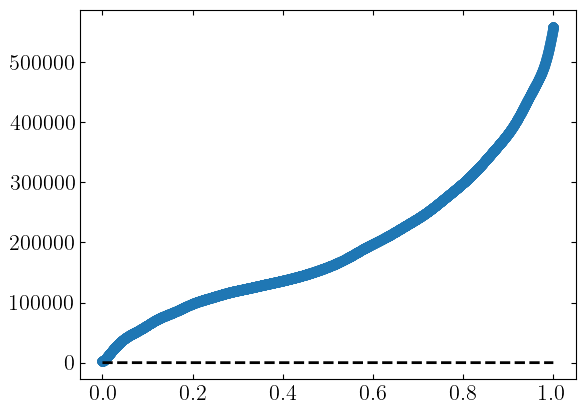

In [18]:
import_reload()
model_Ue = Param_symbol.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
Param_symbol.print_models(df_model_Ue)
Param_symbol.print_best_model(model_Ue)
Param_symbol.pareto_plot(model_Ue)
Param_symbol.parity_plot_Ue(model_Ue, X_train, Y_train, colors=colors, data_set='train')

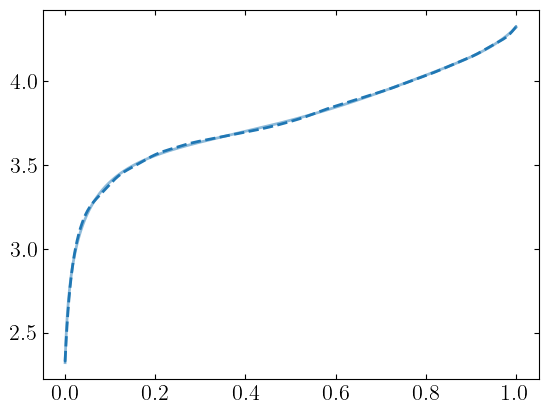

In [19]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [20]:
SAVE  = True
if SAVE:
    Param_symbol.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}')
    Param_symbol.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}')
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')